# Asian Option Extension under the Replicated SABR Simulator

This notebook extends the SABR replication project beyond the European option examples in the paper.

The paper mainly validates the simulation scheme using European call options because accurate FDM benchmark prices are available. However, one of the key advantages of Monte Carlo simulation is that it can naturally handle path-dependent payoffs.

Here, we use the replicated SABR simulation machinery to price arithmetic-average Asian call options:

$$
\text{Payoff} =
\max\left(
\frac{1}{M}\sum_{i=1}^{M} F_{t_i} - K, 0
\right).
$$
The goal is not to reproduce a new table from the paper, but to demonstrate an extension of the implemented SABR simulator to a path-dependent derivative.

## 1. Path simulation with arithmetic averaging

The original `simulate_terminal_forward` function returns only $F_T$, which is enough for European options.

For Asian options, we need the path average. Therefore, this notebook defines a lightweight path simulator that follows the same one-step logic as the paper scheme:

1. exact volatility stepping for $\sigma_{t+h}$;
2. shifted-lognormal sampling of the conditional integrated variance $I_t^h$;
3. martingale-preserving CEV approximation for the next forward price $F_{t+h}$.

At each monitoring date, we store the current forward price and compute the arithmetic average.

In [4]:
def simulate_terminal_and_arithmetic_average(
    params: SABRParams,
    maturity: float,
    n_monitoring: int,
    n_paths: int,
    seed: int = 12345,
):
    """
    Simulate terminal forward values and arithmetic path averages under the replicated SABR scheme.

    The arithmetic average is computed over monitoring dates:
        t_i = i * maturity / n_monitoring, i = 1, ..., n_monitoring

    The initial value F0 is not included in the average.
    """
    if not (0.0 < params.beta < 1.0):
        raise ValueError("This extension notebook focuses on the main SABR case 0 < beta < 1.")

    rng = np.random.default_rng(seed)

    h = maturity / n_monitoring
    beta_star = 1.0 - params.beta
    rho_star_sq = max(0.0, 1.0 - params.rho * params.rho)
    eps = 1e-14

    f = np.full(n_paths, params.f0, dtype=float)
    sigma = np.full(n_paths, params.sigma0, dtype=float)
    running_sum = np.zeros(n_paths, dtype=float)

    for _ in range(n_monitoring):
        absorbed = f <= 0.0
        sigma_next = sample_sigma_next(sigma, params.nu, h, rng)

        if np.all(absorbed):
            sigma = sigma_next
            running_sum += f
            continue

        f_alive = f[~absorbed]
        sigma_alive = sigma[~absorbed]
        sigma_next_alive = sigma_next[~absorbed]

        if abs(params.nu) < eps:
            variance_scale = sigma_alive * sigma_alive * h
            f_next_alive = sample_cev_exact(f_alive, variance_scale, params.beta, rng)
        else:
            ih = sample_conditional_integrated_variance(
                sigma_alive,
                sigma_next_alive,
                params.nu,
                h,
                rng,
            )

            f_pow = np.maximum(f_alive, eps) ** beta_star

            drift = params.rho * (sigma_next_alive - sigma_alive) / (params.nu * f_pow)

            variance_scale = rho_star_sq * sigma_alive * sigma_alive * h * ih

            f_bar = f_alive * np.exp(
                drift
                - 0.5
                * params.rho
                * params.rho
                * sigma_alive
                * sigma_alive
                * h
                * ih
                / np.maximum(f_pow * f_pow, eps)
            )

            f_bar = np.maximum(f_bar, 0.0)

            if rho_star_sq < eps:
                f_next_alive = f_bar
            else:
                f_next_alive = sample_cev_exact(
                    f_bar,
                    variance_scale,
                    params.beta,
                    rng,
                )

        f[~absorbed] = f_next_alive
        sigma = sigma_next
        running_sum += f

    arithmetic_average = running_sum / n_monitoring

    return f, arithmetic_average

## 2. Asian call pricing function

For each simulated path, the arithmetic-average Asian call payoff is:

$$
\max(A_T - K, 0),
$$

where

$$
A_T = \frac{1}{M}\sum_{i=1}^{M}F_{t_i}.
$$

We also compute the European call payoff from the same terminal samples for comparison.

In [5]:
def asian_call_price_from_average(arithmetic_average: np.ndarray, strike: float):
    payoff = np.maximum(arithmetic_average - strike, 0.0)
    price = float(np.mean(payoff))
    stderr = float(np.std(payoff, ddof=1) / math.sqrt(len(payoff)))
    return price, stderr


def european_call_price_from_terminal(terminal: np.ndarray, strike: float):
    payoff = np.maximum(terminal - strike, 0.0)
    price = float(np.mean(payoff))
    stderr = float(np.std(payoff, ddof=1) / math.sqrt(len(payoff)))
    return price, stderr

## 3. Baseline Asian option experiment

We use a moderate SABR parameter set and compare arithmetic Asian call prices with European call prices under the same simulated paths.

A basic expected pattern is that the Asian call is usually cheaper than the European call with the same strike, because averaging reduces the effective volatility of the payoff.

In [6]:
params = SABRParams(
    f0=1.0,
    sigma0=0.25,
    nu=0.5,
    rho=-0.5,
    beta=0.6,
)

maturity = 2.0
strike = 1.0
n_paths = 50_000
n_monitoring = 24

start_time = time.perf_counter()

terminal, arithmetic_average = simulate_terminal_and_arithmetic_average(
    params=params,
    maturity=maturity,
    n_monitoring=n_monitoring,
    n_paths=n_paths,
    seed=20260426,
)

runtime_sec = time.perf_counter() - start_time

asian_price, asian_stderr = asian_call_price_from_average(arithmetic_average, strike)
european_price, european_stderr = european_call_price_from_terminal(terminal, strike)

baseline_result = pd.DataFrame(
    [
        {
            "payoff": "European call",
            "price": european_price,
            "standard_error": european_stderr,
            "strike": strike,
            "maturity": maturity,
            "n_paths": n_paths,
            "n_monitoring": n_monitoring,
            "runtime_sec": runtime_sec,
        },
        {
            "payoff": "Arithmetic Asian call",
            "price": asian_price,
            "standard_error": asian_stderr,
            "strike": strike,
            "maturity": maturity,
            "n_paths": n_paths,
            "n_monitoring": n_monitoring,
            "runtime_sec": runtime_sec,
        },
    ]
)

baseline_result

,payoff,price,standard_error,strike,maturity,n_paths,n_monitoring,runtime_sec
0,European call,0.141361,0.000956,1.000000,2.000000,50000,24,0.297533
1,Arithmetic Asian call,0.084620,0.000546,1.000000,2.000000,50000,24,0.297533


## 4. Monitoring-frequency comparison

Asian option prices depend on how often the average is monitored.

This section compares different monitoring frequencies while keeping the same model parameters, maturity, strike, and number of Monte Carlo paths.

The goal is to show that the replicated SABR simulator can support path-dependent payoff calculations under different monitoring schedules.

In [7]:
monitoring_grid = [4, 12, 24, 52]
monitoring_rows = []

for i, n_monitoring in enumerate(monitoring_grid):
    start_time = time.perf_counter()

    terminal, arithmetic_average = simulate_terminal_and_arithmetic_average(
        params=params,
        maturity=maturity,
        n_monitoring=n_monitoring,
        n_paths=n_paths,
        seed=3000 + i,
    )

    runtime_sec = time.perf_counter() - start_time

    asian_price, asian_stderr = asian_call_price_from_average(arithmetic_average, strike)
    european_price, european_stderr = european_call_price_from_terminal(terminal, strike)

    monitoring_rows.append(
        {
            "n_monitoring": n_monitoring,
            "step_size": maturity / n_monitoring,
            "asian_call_price": asian_price,
            "asian_standard_error": asian_stderr,
            "european_call_price_same_paths": european_price,
            "european_standard_error": european_stderr,
            "asian_minus_european": asian_price - european_price,
            "asian_less_than_european": bool(asian_price <= european_price + 3.0 * asian_stderr),
            "mean_terminal": float(np.mean(terminal)),
            "mean_average": float(np.mean(arithmetic_average)),
            "runtime_sec": runtime_sec,
        }
    )

monitoring_df = pd.DataFrame(monitoring_rows)
monitoring_df

,n_monitoring,step_size,asian_call_price,asian_standard_error,european_call_price_same_paths,european_standard_error,asian_minus_european,asian_less_than_european,mean_terminal,mean_average,runtime_sec
0,4,0.500000,0.096091,0.000626,0.138543,0.000946,-0.042451,True,0.999368,0.999907,0.085418
1,12,0.166667,0.086092,0.000562,0.139362,0.000949,-0.053270,True,0.999516,0.999243,0.131837
2,24,0.083333,0.084690,0.000548,0.141295,0.000961,-0.056605,True,1.002536,1.001362,0.259737
3,52,0.038462,0.082991,0.000535,0.140874,0.000956,-0.057883,True,1.000942,1.000652,0.536507


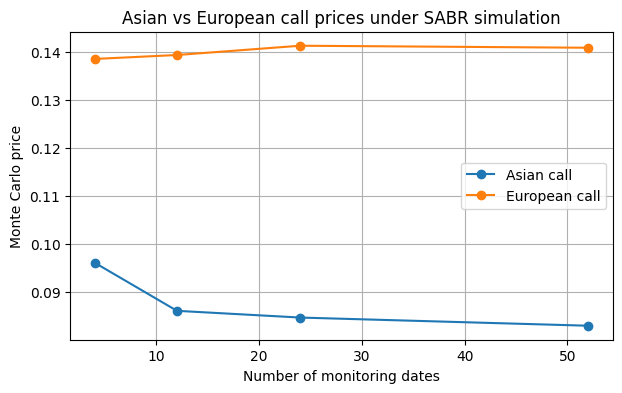

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(monitoring_df["n_monitoring"], monitoring_df["asian_call_price"], marker="o", label="Asian call")
plt.plot(monitoring_df["n_monitoring"], monitoring_df["european_call_price_same_paths"], marker="o", label="European call")
plt.xlabel("Number of monitoring dates")
plt.ylabel("Monte Carlo price")
plt.title("Asian vs European call prices under SABR simulation")
plt.legend()
plt.grid(True)
plt.show()

## 5. Strike comparison

We also compare Asian and European call prices across different strikes.

This checks whether the extension behaves in an economically reasonable way across moneyness levels.

In [9]:
strike_grid = np.linspace(0.7, 1.3, 7)

terminal, arithmetic_average = simulate_terminal_and_arithmetic_average(
    params=params,
    maturity=maturity,
    n_monitoring=24,
    n_paths=n_paths,
    seed=777,
)

strike_rows = []

for k in strike_grid:
    asian_price, asian_stderr = asian_call_price_from_average(arithmetic_average, k)
    european_price, european_stderr = european_call_price_from_terminal(terminal, k)

    strike_rows.append(
        {
            "strike": k,
            "asian_call_price": asian_price,
            "asian_standard_error": asian_stderr,
            "european_call_price": european_price,
            "european_standard_error": european_stderr,
            "asian_minus_european": asian_price - european_price,
            "asian_less_than_european": bool(asian_price <= european_price + 3.0 * asian_stderr),
        }
    )

strike_df = pd.DataFrame(strike_rows)
strike_df

,strike,asian_call_price,asian_standard_error,european_call_price,european_standard_error,asian_minus_european,asian_less_than_european
0,0.700000,0.309918,0.000873,0.344573,0.001320,-0.034655,True
1,0.800000,0.222202,0.000796,0.267148,0.001212,-0.044946,True
2,0.900000,0.145266,0.000684,0.198366,0.001087,-0.053099,True
3,1.000000,0.084207,0.000544,0.140281,0.000949,-0.056074,True
4,1.100000,0.042348,0.000394,0.094510,0.000807,-0.052162,True
5,1.200000,0.018387,0.000261,0.060835,0.000670,-0.042448,True
6,1.300000,0.007081,0.000161,0.038038,0.000547,-0.030957,True


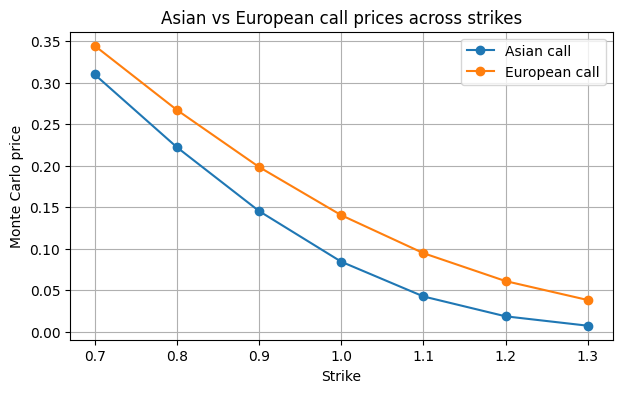

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(strike_df["strike"], strike_df["asian_call_price"], marker="o", label="Asian call")
plt.plot(strike_df["strike"], strike_df["european_call_price"], marker="o", label="European call")
plt.xlabel("Strike")
plt.ylabel("Monte Carlo price")
plt.title("Asian vs European call prices across strikes")
plt.legend()
plt.grid(True)
plt.show()

## 6. Extension sanity checks

We summarize a few simple checks:

1. terminal values are finite and nonnegative;
2. arithmetic averages are finite and nonnegative;
3. Asian call prices are nonnegative;
4. Asian call prices are generally lower than European call prices under the same strike and paths;
5. call prices decrease as strike increases.

In [11]:
asian_prices = strike_df["asian_call_price"].to_numpy()
european_prices = strike_df["european_call_price"].to_numpy()

summary_rows = [
    {
        "check": "terminal values are finite",
        "passed": bool(np.isfinite(terminal).all()),
    },
    {
        "check": "terminal values are nonnegative",
        "passed": bool(np.all(terminal >= 0.0)),
    },
    {
        "check": "arithmetic averages are finite",
        "passed": bool(np.isfinite(arithmetic_average).all()),
    },
    {
        "check": "arithmetic averages are nonnegative",
        "passed": bool(np.all(arithmetic_average >= 0.0)),
    },
    {
        "check": "Asian call prices are nonnegative",
        "passed": bool(np.all(asian_prices >= 0.0)),
    },
    {
        "check": "Asian prices are below or close to European prices",
        "passed": bool(strike_df["asian_less_than_european"].all()),
    },
    {
        "check": "Asian call prices decrease with strike",
        "passed": bool(np.all(np.diff(asian_prices) <= 1e-10)),
    },
    {
        "check": "European call prices decrease with strike",
        "passed": bool(np.all(np.diff(european_prices) <= 1e-10)),
    },
]

extension_summary = pd.DataFrame(summary_rows)
extension_summary

,check,passed
0,terminal values are finite,True
1,terminal values are nonnegative,True
2,arithmetic averages are finite,True
3,arithmetic averages are nonnegative,True
4,Asian call prices are nonnegative,True
5,Asian prices are below or close to European pr...,True
6,Asian call prices decrease with strike,True
7,European call prices decrease with strike,True


## Conclusion

This notebook demonstrates a path-dependent extension of the replicated SABR simulation scheme.

Instead of only pricing European vanilla options, we use the same Monte Carlo machinery to price arithmetic-average Asian call options. The results are economically reasonable:

- Asian call prices are positive and finite;
- Asian prices are generally lower than European call prices with the same strike;
- prices decrease as strike increases;
- the simulator remains stable when path averages are recorded.

This extension highlights why an efficient SABR Monte Carlo scheme is useful beyond the European option benchmark tables reported in the paper.